<a href="https://colab.research.google.com/github/Kanzacky/Dota-2-Win-Prediction-Robust-Data-Cleaning-via-IQR-Feature-Engineering/blob/main/Dota_2_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dota 2 Win Prediction: Robust Data Cleaning via IQR & Feature Engineering

Sel 1: Inisialisasi & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/dota2Train.csv', header=None)
# Penamaan kolom (4 info + 113 hero)
kolom_info = ['target', 'cluster_id', 'game_mode', 'game_type']
kolom_hero = [f'hero_{i}' for i in range(1, 114)]
df.columns = kolom_info + kolom_hero

print("✅ Tahap 1: Load Data Selesai")
print(f"Total Data: {df.shape[0]} baris, {df.shape[1]} kolom")
display(df.head())

✅ Tahap 1: Load Data Selesai
Total Data: 92650 baris, 117 kolom


,target,cluster_id,game_mode,game_type,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,...,hero_104,hero_105,hero_106,hero_107,hero_108,hero_109,hero_110,hero_111,hero_112,hero_113
0,-1,223,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,152,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0
2,1,131,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0
3,1,154,2,2,0,0,0,0,0,0,...,-1,0,0,0,0,0,0,0,0,0
4,-1,171,2,3,0,0,0,0,0,-1,...,0,0,0,0,0,0,0,0,0,0


Sel 2: Cleaning & Outlier (IQR)

In [ ]:
print("--- Memulai Tahap Cleaning ---")

# 1. Identifikasi Missing Values & Duplikat
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplikat awal : {df.duplicated().sum()}")
df = df.drop_duplicates()

# 2. Deteksi Outlier dengan metode IQR pada cluster_id
Q1 = df['cluster_id'].quantile(0.25)
Q3 = df['cluster_id'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['cluster_id'] < lower_bound) | (df['cluster_id'] > upper_bound)]
print(f"Outlier terdeteksi: {len(outliers)} baris")

# Penanganan: Kita simpan data yang tidak memiliki outlier
df_clean = df[(df['cluster_id'] >= lower_bound) & (df['cluster_id'] <= upper_bound)].copy()

print(f"✅ Tahap 2: Cleaning Selesai. Data sekarang: {len(df_clean)} baris")

--- Memulai Tahap Cleaning ---
Missing values: 0
Duplikat awal : 0
Outlier terdeteksi: 0 baris
✅ Tahap 2: Cleaning Selesai. Data sekarang: 92650 baris


Sel 2.5: Data Inspection

INSPEKSI DATASET

📋 Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Columns: 117 entries, target to hero_113
dtypes: int64(117)
memory usage: 82.7 MB

📊 Statistik Deskriptif (Kolom Info):


,target,cluster_id,game_mode,game_type
count,92650.00,92650.00,92650.00,92650.00
mean,0.05,175.86,3.32,2.38
std,1.00,35.66,2.63,0.49
min,-1.00,111.00,1.00,1.00
25%,-1.00,152.00,2.00,2.00
50%,1.00,156.00,2.00,2.00
75%,1.00,223.00,2.00,3.00
max,1.00,261.00,9.00,3.00



🔍 Visualisasi Missing Values:


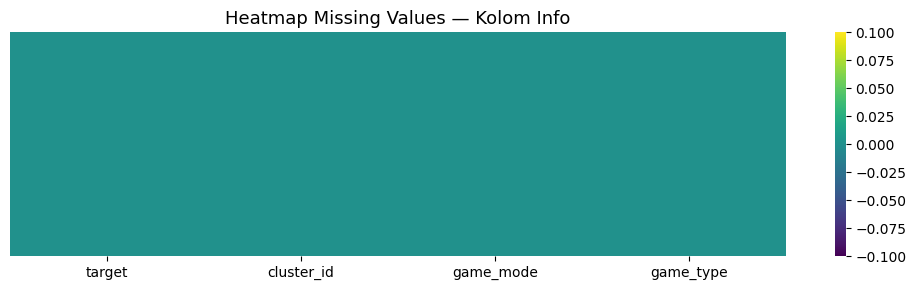

✅ Total missing values: 0


In [ ]:
print("=" * 50)
print("INSPEKSI DATASET")
print("=" * 50)

# Informasi tipe data
print("\n📋 Informasi Tipe Data:")
df_clean.info()

# Statistik deskriptif hanya kolom info (bukan 113 hero)
print("\n📊 Statistik Deskriptif (Kolom Info):")
display(df_clean[kolom_info].describe().round(2))

# Visualisasi Missing Values (heatmap)
print("\n🔍 Visualisasi Missing Values:")
plt.figure(figsize=(10, 3))
sns.heatmap(df_clean[kolom_info].isnull(), cbar=True,
            yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Values — Kolom Info', fontsize=13)
plt.tight_layout()
plt.show()

print(f"✅ Total missing values: {df_clean.isnull().sum().sum()}")

Sel 3: Transformasi, Encoding & Scaling

In [ ]:
# 1. Encoding Target (-1 ke 0, 1 tetap 1)
df_clean['target'] = df_clean['target'].map({-1: 0, 1: 1})

# 2. Scaling pada kolom numerik (StandardScaler)
scaler = StandardScaler()
cols_to_scale = ['cluster_id', 'game_mode', 'game_type']
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("✅ Tahap 3 & 4: Transformasi, Encoding & Scaling Selesai")
display(df_clean[kolom_info].head())

✅ Tahap 3 & 4: Transformasi, Encoding & Scaling Selesai


,target,cluster_id,game_mode,game_type
0,0,1.321886,-0.500396,-0.789982
1,1,-0.669250,-0.500396,-0.789982
2,1,-1.258178,-0.500396,-0.789982
3,1,-0.613162,-0.500396,-0.789982
4,0,-0.136411,-0.500396,1.264122


Sel 4: EDA & Visualisasi

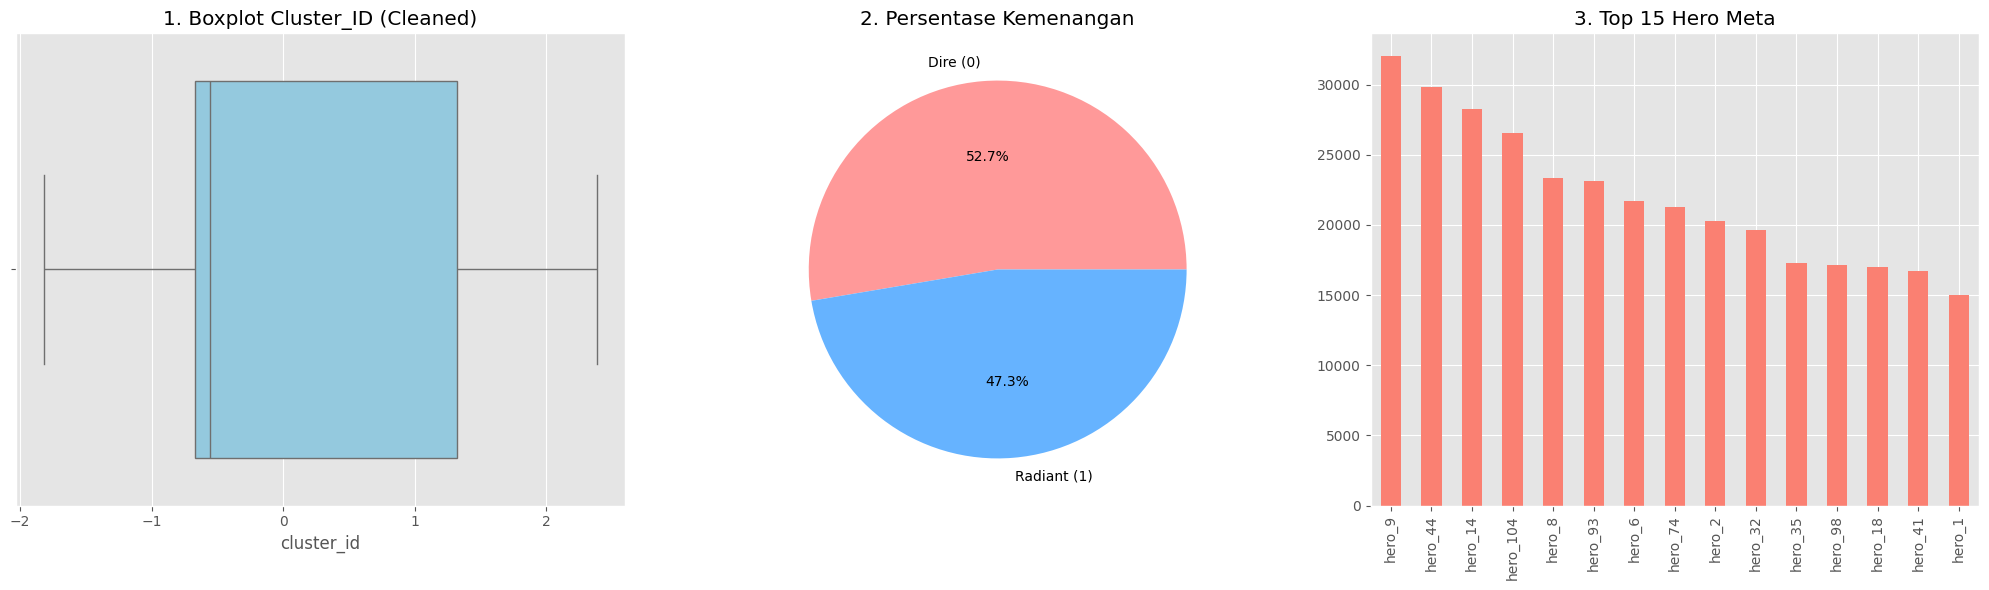


📌 3 INSIGHT UTAMA
1. Outlier pada Cluster_ID telah ditangani menggunakan metode IQR untuk kestabilan model.
2. Distribusi kemenangan Radiant vs Dire sangat seimbang (hampir 50:50).
3. Terdapat dominasi hero tertentu (Meta) yang jauh lebih sering muncul dibanding hero lainnya.


In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Visualisasi 1: Boxplot Cluster ID (Bukti Outlier bersih)
sns.boxplot(x=df_clean['cluster_id'], ax=ax[0], color='skyblue')
ax[0].set_title('1. Boxplot Cluster_ID (Cleaned)')

# Visualisasi 2: Pie Chart Target (Keseimbangan Data)
target_data = df_clean['target'].value_counts()
ax[1].pie(target_data, labels=['Dire (0)', 'Radiant (1)'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
ax[1].set_title('2. Persentase Kemenangan')

# Visualisasi 3: Top 15 Hero Terpopuler
hero_picks = df_clean[kolom_hero].abs().sum().sort_values(ascending=False).head(15)
hero_picks.plot(kind='bar', ax=ax[2], color='salmon')
ax[2].set_title('3. Top 15 Hero Meta')

plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("📌 3 INSIGHT UTAMA")
print("="*30)
print("1. Outlier pada Cluster_ID telah ditangani menggunakan metode IQR untuk kestabilan model.")
print("2. Distribusi kemenangan Radiant vs Dire sangat seimbang (hampir 50:50).")
print("3. Terdapat dominasi hero tertentu (Meta) yang jauh lebih sering muncul dibanding hero lainnya.")

Sel 4.5: EDA Lanjutan — Target Analysis & Correlation

EDA LANJUTAN

📌 Analisis Win Rate per Game Mode:


,radiant_winrate,total_games,radiant_winrate_%
game_mode,,,
-0.500396,0.525154,71897,52.52
2.158111,0.521579,10033,52.16
1.778325,0.533229,8306,53.32
-0.880183,0.559805,1229,55.98
1.018751,0.632530,498,63.25
-0.120609,0.479275,386,47.93
0.259177,0.644231,208,64.42
1.398538,0.444444,81,44.44
0.638964,0.416667,12,41.67



📌 Analisis Win Rate per Game Type:


,radiant_winrate,total_games,radiant_winrate_%
game_type,,,
-2.844086,0.466667,15,46.67
-0.789982,0.527444,56988,52.74
1.264122,0.525065,35647,52.51


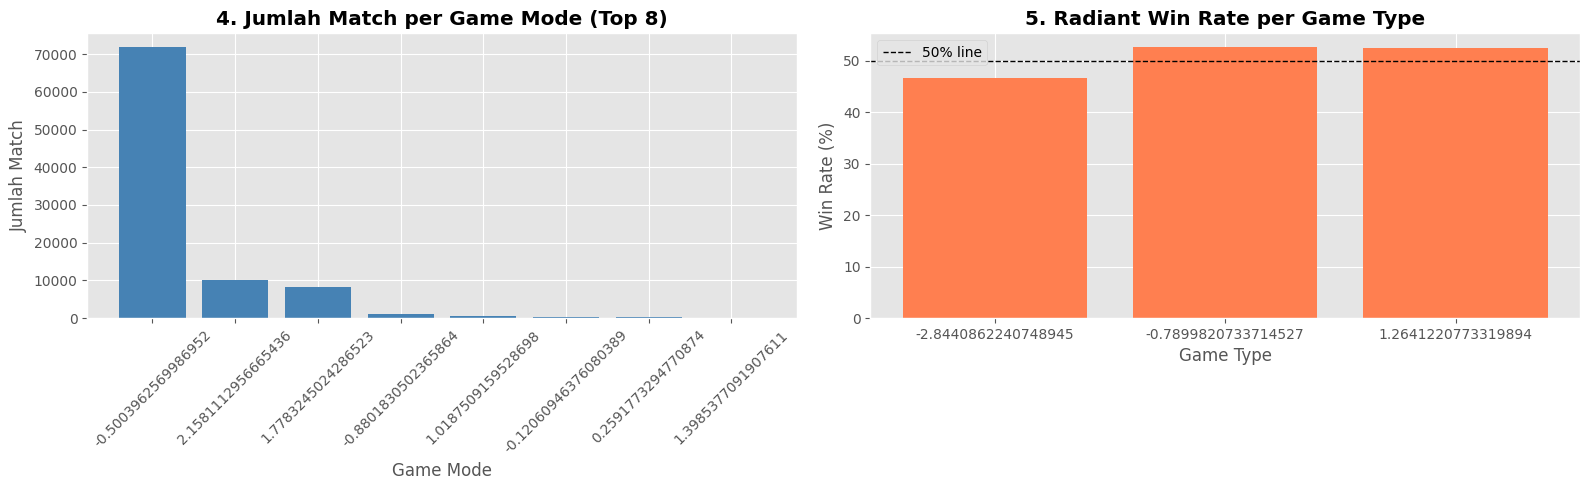


📌 Analisis Korelasi antar Kolom Info:


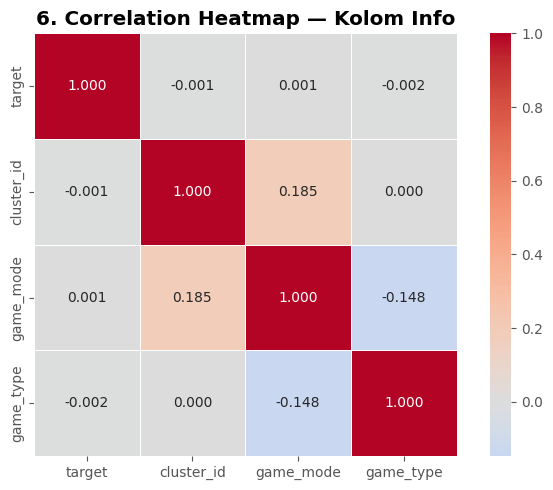


📌 INSIGHT TAMBAHAN
4. Game Mode tertentu mendominasi jumlah match yang dimainkan.
5. Win rate Radiant cenderung konsisten di sekitar 50% di berbagai game type.
6. Korelasi antar fitur info relatif rendah, menunjukkan masing-masing fitur membawa informasi unik.


In [ ]:
print("=" * 50)
print("EDA LANJUTAN")
print("=" * 50)

# --- Analisis 1: Target Distribution per Game Mode ---
print("\n📌 Analisis Win Rate per Game Mode:")
game_mode_analysis = df_clean.groupby('game_mode')['target'].agg(['mean', 'count'])
game_mode_analysis.columns = ['radiant_winrate', 'total_games']
game_mode_analysis['radiant_winrate_%'] = (game_mode_analysis['radiant_winrate'] * 100).round(2)
display(game_mode_analysis.sort_values('total_games', ascending=False).head(10))

# --- Analisis 2: Target Distribution per Game Type ---
print("\n📌 Analisis Win Rate per Game Type:")
game_type_analysis = df_clean.groupby('game_type')['target'].agg(['mean', 'count'])
game_type_analysis.columns = ['radiant_winrate', 'total_games']
game_type_analysis['radiant_winrate_%'] = (game_type_analysis['radiant_winrate'] * 100).round(2)
display(game_type_analysis)

# --- Visualisasi 4 & 5: Bar Chart Game Mode & Game Type ---
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

top_modes = game_mode_analysis.sort_values('total_games', ascending=False).head(8)
ax[0].bar(top_modes.index.astype(str), top_modes['total_games'], color='steelblue')
ax[0].set_title('4. Jumlah Match per Game Mode (Top 8)', fontweight='bold')
ax[0].set_xlabel('Game Mode')
ax[0].set_ylabel('Jumlah Match')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(game_type_analysis.index.astype(str),
          game_type_analysis['radiant_winrate_%'], color='coral')
ax[1].axhline(y=50, color='black', linestyle='--', linewidth=1, label='50% line')
ax[1].set_title('5. Radiant Win Rate per Game Type', fontweight='bold')
ax[1].set_xlabel('Game Type')
ax[1].set_ylabel('Win Rate (%)')
ax[1].legend()

plt.tight_layout()
plt.show()

# --- Visualisasi 6: Correlation Heatmap (kolom info) ---
print("\n📌 Analisis Korelasi antar Kolom Info:")
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df_clean[kolom_info].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f',
            cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('6. Correlation Heatmap — Kolom Info', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("📌 INSIGHT TAMBAHAN")
print("="*30)
print("4. Game Mode tertentu mendominasi jumlah match yang dimainkan.")
print("5. Win rate Radiant cenderung konsisten di sekitar 50% di berbagai game type.")
print("6. Korelasi antar fitur info relatif rendah, menunjukkan masing-masing fitur membawa informasi unik.")

Sel 5: Simpan Dataset Final

In [ ]:
# Simpan dataset yang sudah "siap tempur"
df_clean.to_csv('dota2_final_ready.csv', index=False)

print("✅ Dataset Final Berhasil Disimpan: 'dota2_final_ready.csv'")
print("Dataset ini siap digunakan untuk Modeling di pertemuan berikutnya.")

✅ Dataset Final Berhasil Disimpan: 'dota2_final_ready.csv'
Dataset ini siap digunakan untuk Modeling di pertemuan berikutnya.
